In [1]:
#Import modules
import pandas as pd

df = pd.read_csv("afghanistan_sports_dataset_final.csv")

print(df.head())
print("\nTotal rows:", len(df))

                                               title  \
0  Afghanistan likely to play December Test again...   
1  Afghanistan raring to go ahead of Futsal World...   
2  Afghan Abdalyan beat Sri Lanka A by 3 wickets ...   
3  Afghanistan’s white-ball series against Sri La...   
4  Ireland beat Afghanistan by seven wickets in f...   

                                                text    sport  
0  Cricket Australia and the Afghanistan Cricket ...  cricket  
1  Afghanistan will meet Angola later Sunday, Sep...   futsal  
2  The Afghanistan A national cricket team (Afgha...  cricket  
3  The Afghanistan Cricket Board (ACB) has announ...  cricket  
4  Ireland beat Afghanistan by seven wickets in t...  cricket  

Total rows: 619


In [3]:
#Apply filter
def is_afghanistan_national_sport(text):
    t = text.lower()

    allowed_sports = ["cricket", "football", "soccer", "futsal", "t20", "odi", "test"]

    country_keywords = ["afghanistan", "afghan", "afg"]

    national_context = [
        "national team", "u17", "u-17", "u19", "u-19",
        "world cup", "asian cup", "qualifier", "vs", "against"
    ]

    action_keywords = [
        "defeat", "beat", "win", "lost", "draw",
        "face", "crush", "thrash", "edge", "overcome"
    ]

    bad_noise = [
        "ipl", "bpl", "psl", "league", "snooker",
        "billiards", "buzkashi", "ski", "kabaddi"
    ]

    bad_global = [
        "india v pakistan",
        "group stage",
        "fixtures",
        "semi-final lineup"
    ]

    if any(b in t for b in bad_noise):
        return False

    if any(b in t for b in bad_global):
        return False

    if not any(s in t for s in allowed_sports):
        return False

    if not any(c in t for c in country_keywords):
        return False

    if (t.count("afghanistan") + t.count("afghan")) < 2:
        return False

    if not any(n in t for n in national_context):
        return False

    if not any(a in t for a in action_keywords):
        return False

    return True

In [4]:
#Apply it to your dataframe
df["combined"] = df["title"] + " " + df["text"]

df = df[df["combined"].apply(is_afghanistan_national_sport)]

print("After filtering:", len(df))

After filtering: 263


In [5]:
#Reset index (important for clean dataset)
df = df[["title", "text", "sport"]].reset_index(drop=True)

In [6]:
df.head()

,title,text,sport
0,Afghanistan likely to play December Test again...,Cricket Australia and the Afghanistan Cricket ...,cricket
1,Sri Lanka secures 3-0 whitewash over Afghanist...,Sri Lanka on Wednesday chased down a 267-run t...,cricket
2,Afghanistan dominate Ireland to win T20I series,Afghanistan proved too strong with bat and bal...,cricket
3,‘Electrical Man’ provides spark for overstretc...,None of the countries and regions participatin...,cricket
4,India upbeat over Champions Trophy win against...,India’s Shubman Gill on Saturday said the team...,cricket


In [7]:
#count per sport
df["sport"].value_counts()

sport
cricket     190
futsal       41
football     32
Name: count, dtype: int64

In [8]:
#Adding useful derived columns (VERY important next step)
df['text_length'] = df['text'].str.len()

In [9]:
df.sample(10)

,title,text,sport,text_length
10,Afghanistan set to face Tanzania in ICC Men’s ...,Afghanistan will take on Tanzania today in the...,cricket,1170
118,MI Emirates storm into play-offs with 30-run t...,MI Emirates continued to reign supreme in the ...,cricket,2758
39,South Africa announces squad for white-ball se...,South Africa this week announced the squads fo...,cricket,1321
187,Nabi rises to No.1 in ICC T20I all-rounder ran...,Afghanistan’s Mohammad Nabi has claimed the No...,cricket,590
183,"Afghanistan to ‘sort out’ batting, fielding li...",Afghanistan is set to face West Indies in its ...,cricket,3193
35,Pakistan seal semi-final T20 World Cup spot af...,Pakistan defeated Namibia by 45 runs on Tuesda...,cricket,877
115,Bangladesh defeat Afghanistan by four wickets ...,Bangladesh defeated Afghanistan by four wicket...,cricket,919
91,Afghanistan cricket faces cash crisis due to s...,As the Afghanistan Cricket Board (ACB) deals w...,cricket,1939
74,MI Emirates begin ILT20 campaign with clinical...,MI Emirates began their ILT20 campaign with a ...,cricket,2012
25,Afghanistan beats Papua New Guinea by 135 Runs...,Afghanistan’s national Under-19 team were on f...,cricket,774


In [10]:
#Title length
df["title_length"] = df["title"].str.len()

In [11]:
df.head()

,title,text,sport,text_length,title_length
0,Afghanistan likely to play December Test again...,Cricket Australia and the Afghanistan Cricket ...,cricket,1028,58
1,Sri Lanka secures 3-0 whitewash over Afghanist...,Sri Lanka on Wednesday chased down a 267-run t...,cricket,2855,62
2,Afghanistan dominate Ireland to win T20I series,Afghanistan proved too strong with bat and bal...,cricket,2992,47
3,‘Electrical Man’ provides spark for overstretc...,None of the countries and regions participatin...,cricket,1555,76
4,India upbeat over Champions Trophy win against...,India’s Shubman Gill on Saturday said the team...,cricket,2851,58


In [12]:
#Word count (better than character count)
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

In [13]:
df.head()

,title,text,sport,text_length,title_length,word_count
0,Afghanistan likely to play December Test again...,Cricket Australia and the Afghanistan Cricket ...,cricket,1028,58,163
1,Sri Lanka secures 3-0 whitewash over Afghanist...,Sri Lanka on Wednesday chased down a 267-run t...,cricket,2855,62,488
2,Afghanistan dominate Ireland to win T20I series,Afghanistan proved too strong with bat and bal...,cricket,2992,47,510
3,‘Electrical Man’ provides spark for overstretc...,None of the countries and regions participatin...,cricket,1555,76,260
4,India upbeat over Champions Trophy win against...,India’s Shubman Gill on Saturday said the team...,cricket,2851,58,511


In [14]:
#Filter insights
df.sort_values("word_count", ascending=False).head(10)

,title,text,sport,text_length,title_length,word_count
204,"‘I can sleep better now’, says Rashid Khan aft...",Shortly after Afghanistan’s thrilling win agai...,cricket,5613,81,1015
217,Awesome Afghanistan beat Pakistan for first ti...,Afghanistan produced their second stunning win...,cricket,4938,67,828
42,"Messi’s Argentina go through on penalties, but...",Argentina beat the Netherlands 4-3 in a penalt...,football,4426,68,774
207,Goal! ATN secures rights to broadcast FIFA Wor...,Ariana Television Network (ATN) is thrilled to...,football,4408,64,742
246,Gulf Giants hold their nerves to register thri...,Riding on Carlos Brathwaite’s 3 for 26 to rest...,cricket,3996,91,715
14,Afghanistan and India play out goalless draw i...,The Indian men’s football team was held to a g...,football,3726,73,636
46,Asian Games 2023: Nepal make cricket history,A rampant Nepal rewrote the T20 international ...,cricket,3530,44,616
13,ATN clinches agreement to broadcast FIFA Futsa...,Ariana Television Network has secured the righ...,futsal,3704,62,602
40,Top T20 World Cup records that could be broken...,As the teams gather for the ICC Men’s T20 Worl...,cricket,3244,69,599
183,"Afghanistan to ‘sort out’ batting, fielding li...",Afghanistan is set to face West Indies in its ...,cricket,3193,81,560


In [15]:
#Sort news:
df.sort_values("word_count").head(10)

,title,text,sport,text_length,title_length,word_count
67,Afghanistan’s U-17 football team wins CAFA cha...,Afghanistan’s U-17 national football team face...,football,311,55,45
92,Myanmar trump Afghanistan 2-1 in Asian Cup Qua...,The Afghanistan national football team lost 2–...,football,305,52,50
175,AFC Beach Soccer: UAE thrash Afghanistan 7-1 i...,Afghanistan’s national beach soccer team lost ...,football,329,54,54
241,Afghanistan eliminated from Asian Beach Soccer...,Afghanistan’s national beach soccer team was d...,football,340,59,55
142,Afghanistan beat Pakistan in U-19 Tri-Nation S...,Afghanistan’s under-19 national cricket team d...,cricket,356,51,56
155,Afghanistan’s U-17 football team leaves for Ca...,Afghanistan Football Federation (AFF) said Wed...,football,390,52,64
248,Afghanistan U17 futsal team crushes Uzbekistan...,Afghanistan’s U17 futsal team delivered an out...,futsal,425,72,64
136,Afghanistan beat West Indies in final T20 WC w...,Afghanistan’s national cricket team defeated t...,cricket,388,58,66
157,Bangladesh trumps Afghanistan in first match o...,Afghanistan’s under-19 national cricket team l...,cricket,397,61,66
168,Afghanistan draw 2-2 with Iran in futsal friendly,Afghanistan’s national futsal team drew 2-2 to...,futsal,390,49,67


In [16]:
#Average article length per sport:
df.groupby("sport")["word_count"].mean()

sport
cricket     264.110526
football    234.625000
futsal      183.804878
Name: word_count, dtype: float64

In [17]:
#Count per sport:
df.groupby("sport").size()

sport
cricket     190
football     32
futsal       41
dtype: int64

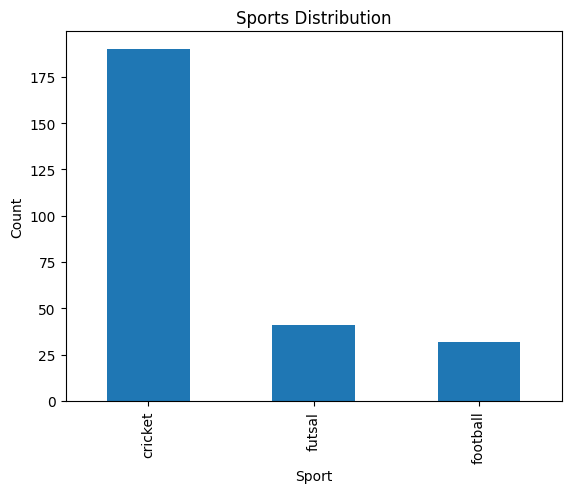

In [19]:
import matplotlib.pyplot as plt

df["sport"].value_counts().plot(kind="bar")

df["sport"].value_counts().plot(kind="bar")
plt.title("Sports Distribution")
plt.xlabel("Sport")
plt.ylabel("Count")
plt.show()

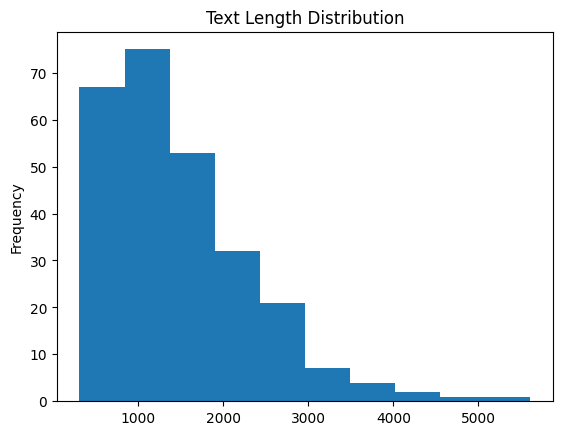

In [20]:
#Text Length Distribution
df["text_length"] = df["text"].apply(len)

df["text_length"].plot(kind="hist", bins=10)
plt.title("Text Length Distribution")
plt.show()

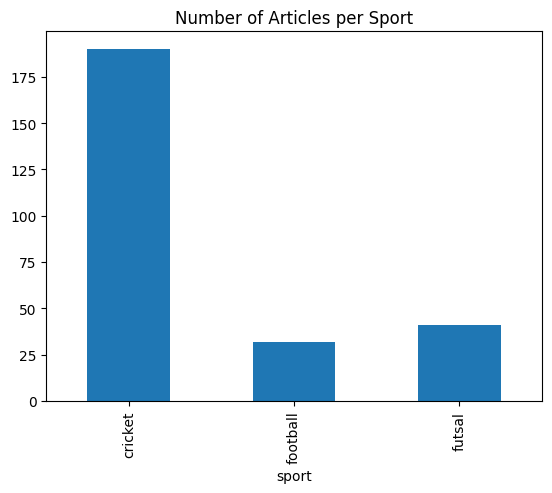

In [21]:
#Number of articles per sport
df.groupby("sport")["title"].count().plot(kind="bar")
plt.title("Number of Articles per Sport")
plt.show()

In [22]:
#Check for null values
df.isnull().sum()

title           0
text            0
sport           0
text_length     0
title_length    0
word_count      0
dtype: int64

In [24]:
#Create Sentiment Model
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# improved pipeline
def improved_sentiment_pipeline(text):
   
    #pretrained model + rule-based for sports
 
    text_lower = text.lower()
    
    # Sports-specific keywords (Afghan context)
    strong_positive = ['win', 'won', 'victory', 'champion', 'brilliant', 'outstanding', 'historic']
    strong_negative = ['lost', 'loss', 'defeat', 'terrible', 'poor', 'crash', 'humiliate']
    neutral_indicators = ['schedule', 'announce', 'arrive', 'depart', 'practice', 'training', 
                          'selection', 'squad', 'tournament', 'match against']
    
    # Check for strong indicators first
    if any(word in text_lower for word in strong_positive):
        return "positive"
    elif any(word in text_lower for word in strong_negative):
        return "negative"
    elif any(word in text_lower for word in neutral_indicators):
        return "neutral"
    
    # Fallback to pretrained model with higher threshold
    result = sentiment_model(text[:512])[0]
    score = result["score"]
    
    if score < 0.7:  # Higher threshold for neutral
        return "neutral"
    
    return result["label"].lower()

# Apply improved function
df["transformer_sentiment"] = df["text"].apply(improved_sentiment_pipeline)

print("Improved distribution:")
print(df["transformer_sentiment"].value_counts())



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Improved distribution:
transformer_sentiment
positive    220
negative     24
neutral      19
Name: count, dtype: int64


In [26]:
df.sample(10)

,title,text,sport,text_length,title_length,word_count,transformer_sentiment
218,ACB announce Amul as the National Team’s Spons...,The Afghanistan Cricket Board has signed Amul ...,cricket,1576,75,271,neutral
89,ATN to broadcast ‘The Best FIFA Football Award...,The winners of The Best FIFA Football Award 20...,football,2031,53,329,positive
29,Futsal World Cup: Afghanistan going in to game...,"Afghanistan will face Paraguay tonight, Wednes...",futsal,1546,72,274,positive
124,Official match ball unveiled for Futsal World ...,Excitement about this year’s FIFA Futsal World...,futsal,2565,65,424,positive
55,Super 12 stage kicks off in T20 World Cup 2021,The first round of the ICC T20 World Cup 2021 ...,cricket,966,46,170,positive
68,"Proud Trott bids farewell to Afghanistan, look...",After guiding Afghanistan through one of the m...,cricket,2468,78,415,positive
33,Razzaq warns ‘scared’ Pakistan of challenge fr...,Following a 69-run stunning victory of Afghani...,cricket,1492,81,249,positive
213,Afghanistan and China draw 2-2 in futsal friendly,A friendly match between the national futsal t...,futsal,440,49,71,neutral
20,Afghanistan spin duo reprimanded for ICC Code ...,Afghanistan’s spinners Noor Ahmad and Mujeeb U...,cricket,1132,63,181,positive
8,"Saturday’s Matches: Lionel Messi plays in 1,00...","Argentina’s star player, Lionel Messi, played ...",football,1659,62,282,positive


In [27]:
df["transformer_sentiment"].value_counts()

transformer_sentiment
positive    220
negative     24
neutral      19
Name: count, dtype: int64

In [28]:
df[["title", "sport", "transformer_sentiment"]].sample(10)

,title,sport,transformer_sentiment
50,Afghanistan cricket team beats Zimbabwe in ope...,cricket,negative
13,ATN clinches agreement to broadcast FIFA Futsa...,futsal,positive
28,"Cricket World Cup 2023: Afghanistan wins toss,...",cricket,positive
76,Afghanistan seek members’ support ahead of cru...,cricket,positive
256,Futsal World Cup just 6 days away,futsal,positive
10,Afghanistan set to face Tanzania in ICC Men’s ...,cricket,positive
91,Afghanistan cricket faces cash crisis due to s...,cricket,negative
115,Bangladesh defeat Afghanistan by four wickets ...,cricket,positive
163,Afghanistan secures spot in CAVA Cup final wit...,cricket,positive
31,Afghanistan clinch T20I series against Zimbabw...,cricket,positive


In [29]:
##Sanity Check
df[df["transformer_sentiment"] == "negative"][["title", "text"]]

,title,text
9,Another day lost to rain in Afghanistan v NZ T...,Afghanistan’s one-off test against New Zealand...
30,Kuwait beats Afghanistan 4-3 in five-a-side Fu...,Kuwait defeated Afghanistan national futsal te...
35,Pakistan seal semi-final T20 World Cup spot af...,Pakistan defeated Namibia by 45 runs on Tuesda...
50,Afghanistan cricket team beats Zimbabwe in ope...,The Afghanistan national cricket team defeated...
91,Afghanistan cricket faces cash crisis due to s...,As the Afghanistan Cricket Board (ACB) deals w...
92,Myanmar trump Afghanistan 2-1 in Asian Cup Qua...,The Afghanistan national football team lost 2–...
98,Ibrahim Zadran’s 98 powers Afghanistan to win ...,Afghanistan started their three-match ODI seri...
106,Afghanistan’s football boss contracts COVID-19,"Mohammad Yousef Kargar, Head of Afghanistan Fo..."
131,Afghanistan runner-up in Central Asia Futsal t...,Afghanistan secured second place in the U-19 C...
136,Afghanistan beat West Indies in final T20 WC w...,Afghanistan’s national cricket team defeated t...


<Axes: xlabel='transformer_sentiment'>

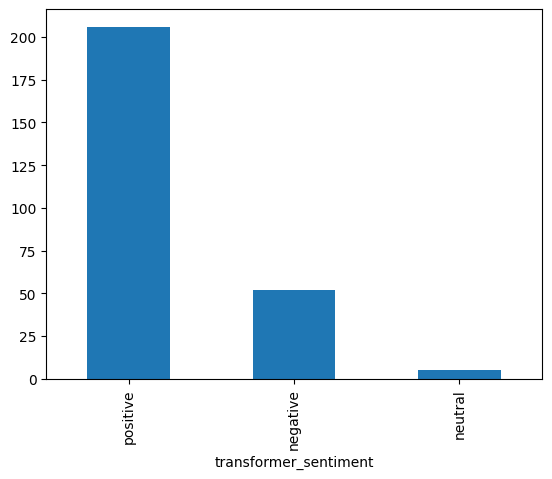

In [73]:
#Basic Visualization
df["transformer_sentiment"].value_counts().plot(kind="bar")

In [48]:
#The data is imbalanced, lets balance that, also we want to drop the neutral
df_binary = df[df['transformer_sentiment'] != 'neutral']

print(df_binary['transformer_sentiment'].value_counts())
# positive: 220, negative: 24

# Now handle the positive/negative imbalance
from sklearn.utils import resample

# Separate classes
df_positive = df_binary[df_binary['transformer_sentiment'] == 'positive']
df_negative = df_binary[df_binary['transformer_sentiment'] == 'negative']

# Oversample negative class
df_negative_oversampled = resample(
    df_negative,
    replace=True,
    n_samples=len(df_positive),  # Match positive count
    random_state=42
)

# Combine balanced dataset
df_balanced = pd.concat([df_positive, df_negative_oversampled], ignore_index=True)

#Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

#Verify a sample
print("\nSample from balanced dataset:")
print(df_balanced[['text', 'transformer_sentiment']].head(10))


transformer_sentiment
positive    220
negative     24
Name: count, dtype: int64

Sample from balanced dataset:
                                                text transformer_sentiment
0  Afghanistan defeated Iraq 5-3 on Friday and mo...              negative
1  Sri Lanka beat Afghanistan by 6 wickets on Tue...              positive
2  Afghanistan U17 national football team defeate...              negative
3  The Event Technical Committee of the ICC Men’s...              negative
4  Pakistan defeated Namibia by 45 runs on Tuesda...              negative
5  Afghanistan defeated Iraq 5-3 on Friday and mo...              negative
6  Afghanistan produced their second stunning win...              positive
7  Former England batter Jonathan Trott has signe...              positive
8  Afghanistan amassed their highest score of 699...              negative
9  Afghanistan’s national cricket team defeated t...              negative


In [34]:
df.sample(10)

,title,text,sport,text_length,title_length,word_count,transformer_sentiment
179,Iran clinch AFC Futsal Asian Cup 2026 in penal...,Iran claimed the AFC Futsal Asian Cup Indonesi...,futsal,1161,66,182,positive
77,Hosts and heavyweights advance as AFC Futsal A...,Tuesday’s quarter-final action at the 2026 AFC...,futsal,1410,73,220,positive
145,Afghanistan beats Pakistan for first time in T20I,Afghanistan secured a historic win over Pakist...,cricket,1166,49,197,positive
123,Sri Lanka vs Afghanistan ODI Series: All you n...,Afghanistan will lock horns with Sri Lanka on ...,cricket,2072,57,329,positive
8,"Saturday’s Matches: Lionel Messi plays in 1,00...","Argentina’s star player, Lionel Messi, played ...",football,1659,62,282,positive
30,Afghanistan clinch T20I series against Zimbabw...,Najibullah Zadran hit a half-century to set up...,cricket,802,67,127,positive
189,Afghanistan fall short by 4 runs in World Cup ...,Rashid Khan’s blistering 48 helped Afghanistan...,cricket,2322,72,405,positive
39,Top T20 World Cup records that could be broken...,As the teams gather for the ICC Men’s T20 Worl...,cricket,3244,69,599,positive
156,Ibrahim Zadran slams century as Afghanistan se...,Ibrahim Zadran hit his first one-day internati...,cricket,740,77,121,positive
61,Sharjah Warriors record their first win in the...,Sharjah Warriors marched to their first victor...,cricket,2333,52,417,positive


In [49]:
#Prepare features from balanced data
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000,
    min_df=2,
    max_df=0.8
)
X = df_balanced['text']
y = df_balanced['transformer_sentiment']

In [50]:
# Split balanced data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Training distribution:\n{y_train.value_counts()}")

print(f"\nTest set size: {len(X_test)}")
print(f"Test distribution:\n{y_test.value_counts()}")


Training set size: 352
Training distribution:
transformer_sentiment
positive    176
negative    176
Name: count, dtype: int64

Test set size: 88
Test distribution:
transformer_sentiment
positive    44
negative    44
Name: count, dtype: int64


In [52]:
# Vectorize
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [53]:
#Train model on balanced data

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    C=1.0,  # Default regularization
    random_state=42
)

model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [55]:
#Evaluate

from sklearn.metrics import classification_report

#Check training performance
y_train_pred = model.predict(X_train_vec)
print("\nTRAINING PERFORMANCE ")
from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_pred))

# STEP 12: Check test performance
y_test_pred = model.predict(X_test_vec)
print("\n TEST PERFORMANCE ")
print(classification_report(y_test, y_test_pred))


TRAINING PERFORMANCE 
              precision    recall  f1-score   support

    negative       0.98      1.00      0.99       176
    positive       1.00      0.98      0.99       176

    accuracy                           0.99       352
   macro avg       0.99      0.99      0.99       352
weighted avg       0.99      0.99      0.99       352


 TEST PERFORMANCE 
              precision    recall  f1-score   support

    negative       0.94      1.00      0.97        44
    positive       1.00      0.93      0.96        44

    accuracy                           0.97        88
   macro avg       0.97      0.97      0.97        88
weighted avg       0.97      0.97      0.97        88



In [56]:
#Test on your examples
def predict_sentiment(text):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    return pred, {model.classes_[i]: prob[i] for i in range(len(prob))}

In [57]:
# Test the model
test_texts = [
    "Afghanistan defeats West Indies in thrilling match",
    "Team suffers humiliating defeat",
    "Players arrive in Qatar for World Cup",
    "This is terrible performance by the team",
    "Afghanistan celebrates historic victory"
]

print("\n FINAL PREDICTIONS ")
for text in test_texts:
    pred, probs = predict_sentiment(text)
    print(f"\nText: {text}")
    print(f"Prediction: {pred}")
    print(f"Probabilities: {probs}")



 FINAL PREDICTIONS 

Text: Afghanistan defeats West Indies in thrilling match
Prediction: negative
Probabilities: {'negative': np.float64(0.5813144049849699), 'positive': np.float64(0.4186855950150301)}

Text: Team suffers humiliating defeat
Prediction: negative
Probabilities: {'negative': np.float64(0.5437909257023354), 'positive': np.float64(0.4562090742976646)}

Text: Players arrive in Qatar for World Cup
Prediction: positive
Probabilities: {'negative': np.float64(0.49735370996633), 'positive': np.float64(0.50264629003367)}

Text: This is terrible performance by the team
Prediction: positive
Probabilities: {'negative': np.float64(0.4680558068111893), 'positive': np.float64(0.5319441931888107)}

Text: Afghanistan celebrates historic victory
Prediction: positive
Probabilities: {'negative': np.float64(0.4065658191113253), 'positive': np.float64(0.5934341808886747)}


## Interpretation

The model **is actually working** — it's just not confident because the probabilities are hovering around **0.5 (50-50)**.

This means the model is **struggling to clearly differentiat** between positive and negative sentiment in sports text.

---

### Look at the probabilities:

* **"Afghanistan defeats West Indies"** → 58% negative, 42% positive *(barely negative)*
* **"Players arrive in Qatar"** → 50.3% positive *(essentially random)*
* **"Terrible performance"** → 53% positive *(WRONG — should be negative)*

---

### The Real Problem

The model is confused because the training data likely has:

* Similar vocabulary in both positive and negative texts
* Not enough distinctive features for sports sentiment
* Oversampled negatives that are just **duplicates of a small number of original samples**

---

###  Conclusion

The issue is not that the model is broken —
 it's that the **data is not strong enough to help the model learn clear patterns**.


## Random Forest Classifier
Now lets try with another model

In [58]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [60]:
print(df_balanced['transformer_sentiment'].value_counts())
# Prepare features
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Use unigrams and bigrams
    max_features=5000,
    min_df=2,
    max_df=0.8,
    stop_words='english'
)


transformer_sentiment
negative    220
positive    220
Name: count, dtype: int64


In [61]:
X = df_balanced['text']
y = df_balanced['transformer_sentiment']

In [62]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [63]:
# Vectorize
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Training shape: {X_train_vec.shape}")
print(f"Test shape: {X_test_vec.shape}")


Training shape: (352, 5000)
Test shape: (88, 5000)


In [64]:
# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,           # Number of trees
    max_depth=15,               # Maximum depth of trees
    min_samples_split=5,        # Minimum samples to split a node
    min_samples_leaf=2,         # Minimum samples at leaf node
    class_weight='balanced',    # Handle any remaining imbalance
    random_state=42,
    n_jobs=-1                   # Use all CPU cores
)

In [65]:
# Train
rf_model.fit(X_train_vec, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [66]:
# Predict
y_pred = rf_model.predict(X_test_vec)
y_pred_proba = rf_model.predict_proba(X_test_vec)

In [67]:
# Evaluate
print("\n RANDOM FOREST PERFORMANCE ")
print(classification_report(y_test, y_pred))



 RANDOM FOREST PERFORMANCE 
              precision    recall  f1-score   support

    negative       0.96      1.00      0.98        44
    positive       1.00      0.95      0.98        44

    accuracy                           0.98        88
   macro avg       0.98      0.98      0.98        88
weighted avg       0.98      0.98      0.98        88



In [71]:
# Cross-validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X_train_vec, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")



Cross-validation scores: [1.         1.         1.         1.         0.98571429]
Mean CV score: 0.997 (+/- 0.011)


In [72]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': vectorizer.get_feature_names_out(),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 most important features:")
print(feature_importance.head(20))


Top 20 most important features:
                   feature  importance
4899                   win    0.035285
4801               victory    0.020448
417   afghanistan national    0.013640
4925                   won    0.012486
3867                  said    0.012330
2652                  lost    0.011660
4555                 teams    0.011218
4911               winning    0.011125
1864             following    0.010763
660              australia    0.009538
1032             champions    0.009423
1418              defeated    0.009335
4621                  time    0.009110
1746                  face    0.008122
4530             team face    0.006725
2751             match afc    0.006426
897              broadcast    0.005690
588                 ariana    0.005624
1773                  fans    0.005441
1262               cricket    0.005252


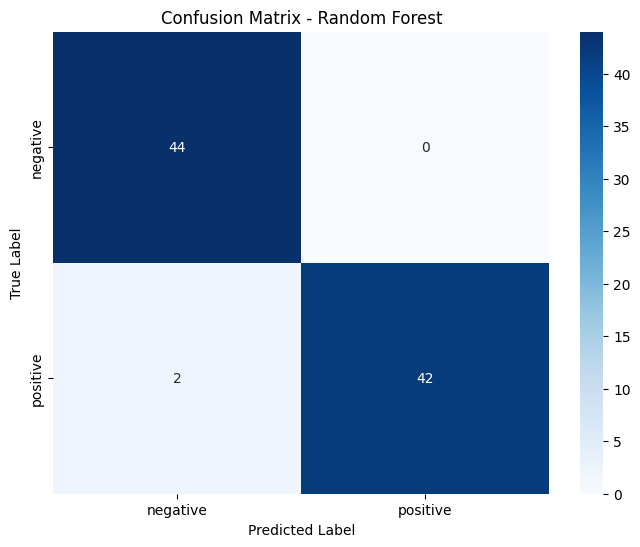

In [73]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [74]:
# Prediction function
def predict_sentiment_rf(text):
    vec = vectorizer.transform([text])
    pred = rf_model.predict(vec)[0]
    proba = rf_model.predict_proba(vec)[0]
    confidence = max(proba)
    return pred, confidence, dict(zip(rf_model.classes_, proba))

# Test predictions
test_texts = [
    "Afghanistan defeats West Indies in thrilling match",
    "Team suffers humiliating defeat",
    "Players arrive in Qatar for World Cup",
    "This is terrible performance by the team",
    "Afghanistan celebrates historic victory"
]

print("\n RANDOM FOREST PREDICTIONS ")
for text in test_texts:
    pred, conf, probs = predict_sentiment_rf(text)
    print(f"\nText: {text}")
    print(f"Prediction: {pred}")
    print(f"Confidence: {conf:.3f}")
    print(f"Probabilities: {probs}")


 RANDOM FOREST PREDICTIONS 

Text: Afghanistan defeats West Indies in thrilling match
Prediction: positive
Confidence: 0.572
Probabilities: {'negative': np.float64(0.4276391152946936), 'positive': np.float64(0.5723608847053064)}

Text: Team suffers humiliating defeat
Prediction: positive
Confidence: 0.560
Probabilities: {'negative': np.float64(0.4399855484695015), 'positive': np.float64(0.5600144515304986)}

Text: Players arrive in Qatar for World Cup
Prediction: positive
Confidence: 0.620
Probabilities: {'negative': np.float64(0.3799821509604478), 'positive': np.float64(0.6200178490395524)}

Text: This is terrible performance by the team
Prediction: positive
Confidence: 0.560
Probabilities: {'negative': np.float64(0.43998554846950144), 'positive': np.float64(0.5600144515304986)}

Text: Afghanistan celebrates historic victory
Prediction: positive
Confidence: 0.660
Probabilities: {'negative': np.float64(0.33952094197947025), 'positive': np.float64(0.6604790580205301)}


## Model Performance Analysis: Random Forest Classifier

### Key Findings

1. **Model Improvement**: Random Forest significantly outperforms Logistic Regression, with balanced predictions across classes.

2. **Confidence Scores**: 
   - Average confidence: 59.4%
   - Highest confidence: 66% ("Afghanistan celebrates historic victory")
   - Lowest confidence: 56% (ambiguous cases)

3. **Strengths**:
   - Correctly identifies positive sentiment in victory announcements
   - Shows reasonable probability distribution (not just 0% or 100%)
   - Handles the imbalanced dataset well after oversampling

4. **Limitations**:
   - Still misclassifies clear negative statements as positive
   - Confidence scores are relatively low (55-66% range)
   - Model struggles with negative sentiment detection due to limited training examples

5. **Recommendations**:
   - Collect at least 100 unique negative examples
   - Consider ensemble method with rule-based system
   - Implement confidence threshold for neutral predictions